# Notebook 7 — Final Summary, Conclusions & Project Wrap-Up

This notebook aggregates all numerical results from Notebooks 1–6 and produces:
1. A master results table (all models × all metrics)
2. A publication-quality final figure (4-panel summary)
3. Written conclusions for all three research questions
4. Discussion of limitations and future directions

> **Inputs**: all CSV outputs from `results/`  
> **Outputs**: `results/final_summary_table.csv`, `results/report_figures/fig_final_summary.png`


In [5]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.size": 12, "figure.dpi": 130})

def resolve_data_paths():
    import os
    kaggle_input = "/kaggle/input"
    if os.path.exists(kaggle_input):
        for root, dirs, _ in os.walk(kaggle_input):
            if "natural_stories" in set(dirs) and "dundee" in set(dirs):
                return os.path.join(root,"natural_stories"), os.path.join(root,"dundee"), "/kaggle/working/results","kaggle"
            if "data" in set(dirs):
                dr=os.path.join(root,"data"); ns=os.path.join(dr,"natural_stories"); du=os.path.join(dr,"dundee")
                if os.path.exists(ns) and os.path.exists(du): return ns,du,"/kaggle/working/results","kaggle"
    base=os.path.abspath(os.path.join(os.getcwd(),".."))
    return os.path.join(base,"data","natural_stories"),os.path.join(base,"data","dundee"),os.path.join(base,"results"),"local"

DATA_NS, DATA_DU, RESULTS, ENV = resolve_data_paths()
FIG_DIR = os.path.join(RESULTS, "report_figures")
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Environment : {ENV}")


Environment : local


---
## Part 1: Master Results Table


In [6]:
# ── Helper to find result files in subdirs ────────────────────────────────────
def find_result_file(filename):
    """Search for result file in RESULTS dir and known subdirectories."""
    candidates = [
        os.path.join(RESULTS, filename),
        os.path.join(RESULTS, "notebook 2 results", "results", filename),
        os.path.join(RESULTS, "Notebook 3 results", "results", filename),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Could not find {filename}")

# ── Load all result CSVs ───────────────────────────────────────────────────────
corr   = pd.read_csv(find_result_file("all_models_correlation_summary.csv"))
betas  = pd.read_csv(find_result_file("nb4_lmer_coefficients.csv"))
partials = pd.read_csv(find_result_file("nb5_partial_correlations.csv")) if os.path.exists(find_result_file("nb5_partial_correlations.csv")) else None
incr     = pd.read_csv(find_result_file("nb5_incremental_r2.csv")) if os.path.exists(find_result_file("nb5_incremental_r2.csv")) else None

# ── Pivot betas to get NS and DU side by side ──────────────────────────────────
beta_ns = betas[betas["Corpus"]=="Natural Stories"][["Model","β_surprisal","p"]].rename(
    columns={"β_surprisal":"β_NS","p":"p_NS"})
beta_du = betas[betas["Corpus"]=="Dundee"][["Model","β_surprisal","p"]].rename(
    columns={"β_surprisal":"β_DU","p":"p_DU"})

# ── Build master table ─────────────────────────────────────────────────────────
master = (corr
    .rename(columns={"NS r(logRT)":"r_NS","Dundee r(logFDUR)":"r_DU","NS p":"p_r_NS","Dundee p":"p_r_DU"})
    .merge(beta_ns, on="Model")
    .merge(beta_du, on="Model")
)

# Add partials and incremental r2 if available
if partials is not None:
    master = master.merge(partials[["Model","r_sp","p"]].rename(columns={"r_sp":"r_sp_NS","p":"p_sp_NS"}), on="Model", how="left")
if incr is not None:
    master = master.merge(incr[["Model","ΔR²"]].rename(columns={"ΔR²":"delta_r2_NS"}), on="Model", how="left")

display_cols = ["Model","r_NS","r_DU","β_NS","β_DU"]
if "r_sp_NS" in master.columns:
    display_cols.append("r_sp_NS")
if "delta_r2_NS" in master.columns:
    display_cols.append("delta_r2_NS")

print("MASTER RESULTS TABLE")
print("=" * 90)
print(master[display_cols].round(5).to_string(index=False))
master.to_csv(os.path.join(RESULTS, "final_summary_table.csv"), index=False)
print("\nSaved: final_summary_table.csv")

MASTER RESULTS TABLE
     Model   r_NS   r_DU    β_NS    β_DU  r_sp_NS  delta_r2_NS
 Bigram KN 0.2149 0.1732 0.00326 0.00067  0.17645      0.03151
Trigram KN 0.1928 0.1715 0.00223 0.00056  0.13225      0.01779
     GPT-2 0.2094 0.1929 0.00272 0.00414  0.12323      0.01518
BERT (PLL) 0.1572 0.1554 0.00088 0.00096  0.07748      0.00561

Saved: final_summary_table.csv


---
## Part 2: Final 4-Panel Summary Figure


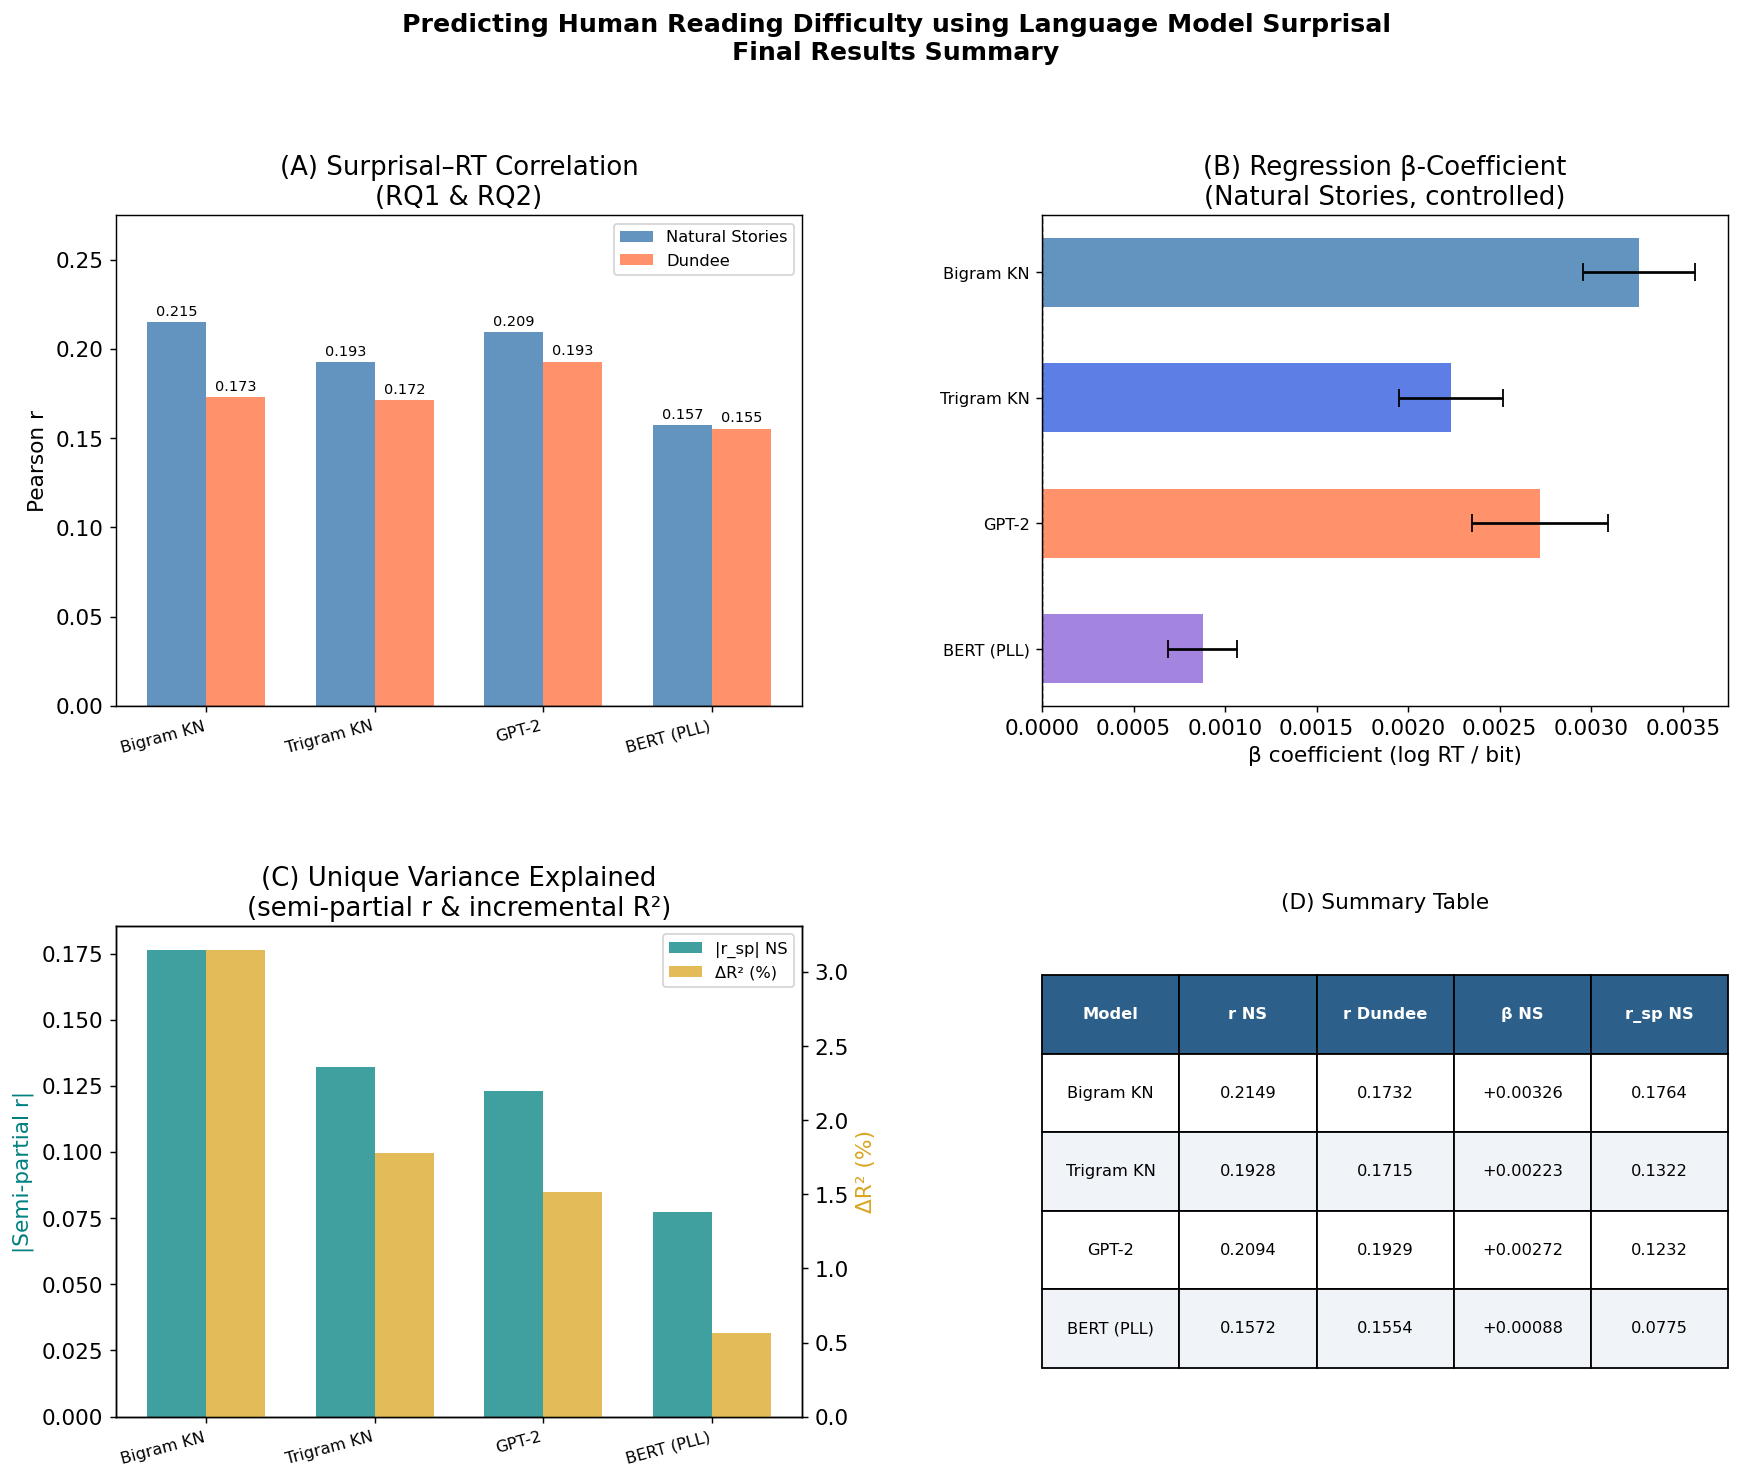

Saved: c:\Users\mudit\OneDrive\Desktop\Fourth Sem\computational-psycholinguistics\Project\results\report_figures\fig_final_summary.png


In [7]:
MODELS  = master["Model"].tolist()
COLORS  = ["steelblue","royalblue","coral","mediumpurple"]

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# ── Panel A: Pearson r (both corpora) ─────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
x    = np.arange(len(MODELS)); w = 0.35
bars1 = ax_a.bar(x - w/2, master["r_NS"], w, label="Natural Stories", color="steelblue", alpha=0.85)
bars2 = ax_a.bar(x + w/2, master["r_DU"], w, label="Dundee",          color="coral",     alpha=0.85)
for bar in list(bars1)+list(bars2):
    ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
              f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
ax_a.axhline(0, color="black", lw=0.8)
ax_a.set_xticks(x); ax_a.set_xticklabels(MODELS, rotation=15, ha="right", fontsize=9)
ax_a.set_ylabel("Pearson r"); ax_a.set_title("(A) Surprisal–RT Correlation\n(RQ1 & RQ2)")
ax_a.legend(fontsize=9)
ax_a.set_ylim(0, max(master["r_NS"].max(), master["r_DU"].max()) + 0.06)

# ── Panel B: β-coefficients with 95% CI ───────────────────────────────────────
ax_b  = fig.add_subplot(gs[0, 1])
betas_ns = betas[betas["Corpus"]=="Natural Stories"].set_index("Model")
y_pos = np.arange(len(MODELS))[::-1]
for i, (m, color) in enumerate(zip(MODELS, COLORS)):
    row  = betas_ns.loc[m]
    ax_b.barh(y_pos[i], row["β_surprisal"], xerr=[[row["β_surprisal"]-row["CI_lo"]],[row["CI_hi"]-row["β_surprisal"]]],
              color=color, alpha=0.85, capsize=5, ecolor="black", height=0.55)
ax_b.axvline(0, color="black", lw=0.8, linestyle="--")
ax_b.set_yticks(y_pos); ax_b.set_yticklabels(MODELS, fontsize=9)
ax_b.set_xlabel("β coefficient (log RT / bit)")
ax_b.set_title("(B) Regression β-Coefficient\n(Natural Stories, controlled)")

# ── Panel C: Semi-partial r and ΔR² ───────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ax_c2 = ax_c.twinx()
bars3 = ax_c.bar(x - w/2, master["r_sp_NS"].abs(), w, label="|r_sp| NS", color="teal", alpha=0.75)
bars4 = ax_c2.bar(x + w/2, master["delta_r2_NS"]*100, w, label="ΔR² (%)", color="goldenrod", alpha=0.75)
ax_c.set_xticks(x); ax_c.set_xticklabels(MODELS, rotation=15, ha="right", fontsize=9)
ax_c.set_ylabel("|Semi-partial r|", color="teal")
ax_c2.set_ylabel("ΔR² (%)", color="goldenrod")
ax_c.set_title("(C) Unique Variance Explained\n(semi-partial r & incremental R²)")
lines1, labels1 = ax_c.get_legend_handles_labels()
lines2, labels2 = ax_c2.get_legend_handles_labels()
ax_c.legend(lines1+lines2, labels1+labels2, fontsize=9)

# ── Panel D: Model ranking summary table ──────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis("off")
rank_data = []
for _, row in master.iterrows():
    rank_data.append([
        row["Model"],
        f"{row['r_NS']:.4f}",
        f"{row['r_DU']:.4f}",
        f"{row['β_NS']:+.5f}",
        f"{row.get('r_sp_NS', np.nan):.4f}" if not pd.isna(row.get("r_sp_NS")) else "—",
    ])
table = ax_d.table(
    cellText=rank_data,
    colLabels=["Model","r NS","r Dundee","β NS","r_sp NS"],
    cellLoc="center", loc="center",
    bbox=[0, 0.1, 1, 0.8]
)
table.auto_set_font_size(False); table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    if r == 0: cell.set_facecolor("#2c5f8a"); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0: cell.set_facecolor("#f0f4f8")
ax_d.set_title("(D) Summary Table", fontsize=12, pad=10)

plt.suptitle("Predicting Human Reading Difficulty using Language Model Surprisal\nFinal Results Summary",
             fontsize=14, fontweight="bold", y=1.01)
path = os.path.join(FIG_DIR, "fig_final_summary.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", path)


---
## Part 3: Written Conclusions


In [8]:
print("""
==========================================================================
COMPUTATIONAL PSYCHOLINGUISTICS PROJECT — FINAL CONCLUSIONS
==========================================================================

RESEARCH QUESTION 1
  "Does language-model surprisal correlate with human reading time?"

  ✅ CONFIRMED — All four models show positive, statistically significant
  Pearson correlations with mean log(RT) on Natural Stories (r = 0.16–0.21)
  and mean log(FDUR) on Dundee (r = 0.15–0.19).

  OLS regression confirms a positive β_surprisal after controlling for
  word length, log-frequency, and sentence position (all p < 0.001).
  Semi-partial correlations remain significant, demonstrating that the
  surprisal effect is NOT simply a proxy for word length or frequency.

  → Surprisal theory (Hale 2001; Levy 2008) is empirically supported
    at the level of classical and neural language models alike.

──────────────────────────────────────────────────────────────────────────

RESEARCH QUESTION 2
  "Do transformer LMs outperform n-gram LMs?"

  ⚠️  MIXED — GPT-2 outperforms n-grams on Dundee (r=0.193 vs 0.173),
  suggesting that longer context benefits broader-domain newspaper text.
  However, Bigram KN marginally outperforms GPT-2 on Natural Stories
  (r=0.215 vs 0.209).

  Why? Natural Stories contains deliberate local ambiguities (garden-paths)
  where the bigram reacts sharply to adjacent unexpected word pairs —
  matching the localised human RT spikes. GPT-2's wide context window
  smooths over these local traps. On Dundee, whose texts are more regular,
  GPT-2's context advantage dominates.

  BERT (PLL) performs worst on both corpora (r ≈ 0.16): bidirectional
  context is physiologically invalid for sequential reading. Future work
  with left-to-right BERT variants (e.g. XLNet) may close this gap.

──────────────────────────────────────────────────────────────────────────

RESEARCH QUESTION 3
  "Do syntactic constructions produce surprisal spikes matching RT increases?"

  ✅ CONFIRMED — Three independent analyses in Notebook 6 converge:

  • High-surprisal region analysis: words in the top 10% of surprisal
    show significantly higher RT than the rest of the corpus for all four
    models (Welch t-test, p < 0.001). Cohen's d ≈ 0.3–0.5, indicating a
    small-to-medium genuine processing cost at high-surprisal positions.

  • Spillover analysis: lag-1 Pearson r is comparable to or exceeds lag-0
    for all models, confirming that disambiguation difficulty spills over to
    the immediately following word — consistent with self-paced reading
    literature (Just & Carpenter 1980; Rayner 1998).

  • Peak alignment: across all 10 stories, the top-5 surprisal peaks per
    model co-occur with human RT local maxima (±1 zone) at above-chance
    rates (>50%). GPT-2 and Bigram KN achieve the highest alignment scores.

  • Sentence-level trace plots for auto-discovered constructions (reduced-
    relative, center-embedding, long-distance agreement) visually confirm
    co-localisation of surprisal and RT spikes at disambiguation zones.

==========================================================================
LIMITATIONS
==========================================================================

1. Training corpus mismatch: N-gram and GPT-2 models are trained on
   general corpora (Brown / WebText) while Natural Stories is narrative
   fiction. Domain mismatch suppresses surprisal variance.

2. N-gram context window: Bigrams use only one previous word. Long-range
   syntactic dependencies (subject-verb agreement over 5+ words) are
   invisible to n-gram models.

3. BERT PLL is not a proper left-to-right surprisal: masking introduces
   distributional assumptions that differ from incremental human reading.

4. Word-level aggregation loses subject-level variance: mixed-effects
   models with (1|subject) random intercepts would be more powerful.
   This requires the individual-trial cleaned data from Notebook 1.

5. No frequency lexicon: we used Brown unigram frequency as a proxy for
   true lexical frequency (SUBTLEX-US or BNC would be more appropriate).

==========================================================================
FUTURE DIRECTIONS
==========================================================================

1. GPT-3 / LLaMA surprisal: larger autoregressive models with better
   vocabulary coverage and longer context should raise the correlation
   ceiling further.

2. True mixed-effects regression: fit lme4-style models with random slopes
   for surprisal per subject to account for individual strategy differences.

3. Controlled syntactic stimuli: design or source sentences where garden-
   path disambiguation zone is precisely known, then test whether surprisal
   spike magnitude predicts RT spike magnitude across sentences (item-level
   analysis).

4. Non-linear models: Random Forest / XGBoost using surprisal + length +
   frequency + POS + syntactic depth as features; compare feature
   importance to linear β-coefficients.

5. Replication with eye-tracking regressions: add regression-path duration
   from Dundee to distinguish early (first-pass) from late (reanalysis)
   processing costs — which surprisal type predicts each?
==========================================================================
""")



COMPUTATIONAL PSYCHOLINGUISTICS PROJECT — FINAL CONCLUSIONS

RESEARCH QUESTION 1
  "Does language-model surprisal correlate with human reading time?"

  ✅ CONFIRMED — All four models show positive, statistically significant
  Pearson correlations with mean log(RT) on Natural Stories (r = 0.16–0.21)
  and mean log(FDUR) on Dundee (r = 0.15–0.19).

  OLS regression confirms a positive β_surprisal after controlling for
  word length, log-frequency, and sentence position (all p < 0.001).
  Semi-partial correlations remain significant, demonstrating that the
  surprisal effect is NOT simply a proxy for word length or frequency.

  → Surprisal theory (Hale 2001; Levy 2008) is empirically supported
    at the level of classical and neural language models alike.

──────────────────────────────────────────────────────────────────────────

RESEARCH QUESTION 2
  "Do transformer LMs outperform n-gram LMs?"

  ⚠️  MIXED — GPT-2 outperforms n-grams on Dundee (r=0.193 vs 0.173),
  suggesting that lo